# Quick check: temporal distribution of LL outliers

It verifies if the outliers flagged by `find_outlier_rows` are concentrated in the initial ramp-up or spread out over the entire run.

In [1]:
import os

from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: /Users/antoniosirignano/Desktop/Progetto Impianti di Elaborazione/02 - PCA & Clustering/workload-characterization


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from analysis.clean import load_dataset, find_outlier_rows

## 1. Load the dataset and find the outliers
Change `csv_path` to repeat the check on `ll_global.csv`.

In [3]:
csv_path = Path("data/raw/ll_global.csv")
df = load_dataset(csv_path)

outliers = find_outlier_rows(df, z_threshold=4.0)
print(f"{len(outliers)} outlier rows on {len(df)} ({len(outliers)/len(df)*100:.2f}%)")

Loaded ll_global.csv: 3615 rows, 14 columns.
142 outlier rows on 3615 (3.93%)


## 2. Index outliers position
If they're concentrated at the beginning (ramp-up), you should see almost all small values.

In [4]:
print("Indees of outlier rows:")
print(outliers.index.tolist())

print(f"\nMinimum index: {outliers.index.min()}")
print(f"Max index: {outliers.index.max()}")
print(f"Median index: {outliers.index.to_series().median()}")

Indees of outlier rows:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 68, 171, 308, 325, 376, 393, 513, 530, 547, 564, 598, 615, 632, 990, 1007, 1024, 1144, 1161, 1178, 1195, 1246, 1263, 1280, 1544, 1545, 1546, 1547, 1555, 1775, 1792, 1856, 1865, 1867, 1868, 1871, 1874, 1879, 1887, 1897, 1906, 1927, 1930, 1934, 1951, 1968, 1985, 2002, 2053, 2121, 2138, 2155, 2172, 2218, 2275, 2292, 2309, 2343, 2360, 2377, 2411, 2462, 2479, 2496, 2513, 2818, 2852, 2937, 2954, 2971, 2988, 3005, 3022, 3036, 3039, 3049, 3227, 3244, 3261, 3278, 3295, 3312, 3329, 3346, 3363, 3380, 3567, 3584, 3592, 3593, 3594, 3595, 3596, 3597, 3598, 3599, 3600, 3601, 3602, 3603, 3604, 3605, 3606, 3607, 3608, 3609, 3610, 3611, 3612, 3613, 3614]

Minimum index: 0
Max index: 3614
Median index: 1901.5


## 2. Histogram of the temporal location of outliers
A peak near 0 that quickly fades indicates a ramp-up. Outliers scattered throughout the range indicate actual system noise.

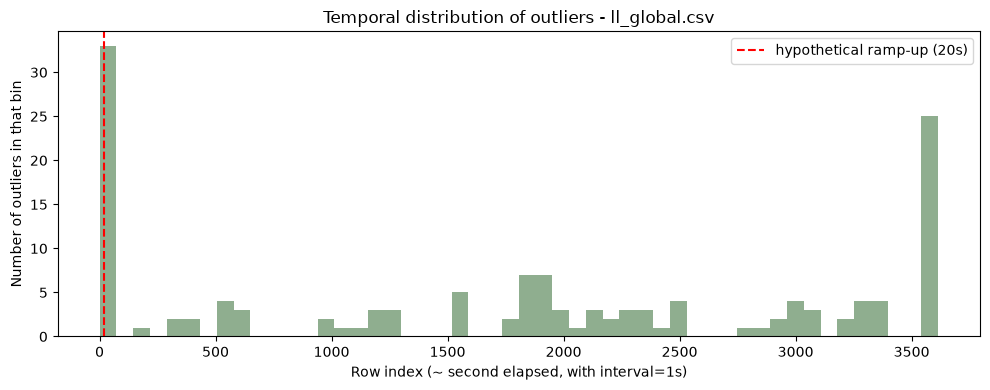

In [5]:
plt.figure(figsize=(10, 4))
plt.hist(outliers.index, bins=50, color="#8fae8f")
plt.xlabel("Row index (~ second elapsed, with interval=1s)")
plt.ylabel("Number of outliers in that bin")
plt.title(f"Temporal distribution of outliers - {csv_path.name}")
plt.axvline(x=20, color="red", linestyle="--", label="hypothetical ramp-up (20s)")
plt.legend()
plt.tight_layout()

out_dir = Path("analysis/plots")
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / f"outlier_timeline_{csv_path.stem}.png")
plt.show()

## 4. Inside vs Outside outliers in the hypothetical ramp-up window
Change `RAMP_UP_CANDIDATE` to test different threshold (15, 20, 30...).

In [6]:
RAMP_UP_CANDIDATE = 20

inside_rampup = outliers[outliers.index < RAMP_UP_CANDIDATE]
outside_rampup = outliers[outliers.index > RAMP_UP_CANDIDATE]

print(f"Outliers inside the first {RAMP_UP_CANDIDATE}s (ramp-up): {len(inside_rampup)}")
print(f"Outliers outside the first {RAMP_UP_CANDIDATE}s (ramp-up): {len(outside_rampup)}")

if len(outside_rampup) > 0:
    print(f"Sample of outlier outside the ramp-up: {len(outside_rampup)}")
    display(outside_rampup.head(10))

Outliers inside the first 20s (ramp-up): 20
Outliers outside the first 20s (ramp-up): 121
Sample of outlier outside the ramp-up: 121


,timestamp,cpu_percent,mem_total,mem_available,mem_used,mem_free,mem_percent,swap_used,swap_free,swap_percent,disk_read_bytes_delta,disk_write_bytes_delta,net_bytes_sent_delta,net_bytes_recv_delta
21,2026-08-21T13:29:24.973558+00:00,26.6,17179869184,4889333760,8599543808,469749760,71.5,3631742976,1736966144,67.6,2908160,106496,220657664,220647424
22,2026-08-21T13:29:25.979813+00:00,29.0,17179869184,4860022784,8627793920,440905728,71.7,3631742976,1736966144,67.6,7774208,8192,223516672,223502336
23,2026-08-21T13:29:26.983677+00:00,25.7,17179869184,4834275328,8651141120,416034816,71.9,3631742976,1736966144,67.6,2097152,4096,234901504,234886144
24,2026-08-21T13:29:27.988015+00:00,24.0,17179869184,4846194688,8637775872,432234496,71.8,3631742976,1736966144,67.6,3842048,3710976,233648128,233637888
25,2026-08-21T13:29:28.998008+00:00,26.2,17179869184,4834656256,8645013504,433512448,71.9,3631742976,1736966144,67.6,3653632,0,228660224,228639744
26,2026-08-21T13:29:30.002191+00:00,29.3,17179869184,4838174720,8640270336,453144576,71.8,3631742976,1736966144,67.6,4710400,0,209108992,209087488
27,2026-08-21T13:29:31.007208+00:00,27.7,17179869184,4806344704,8661700608,408932352,72.0,3598188544,1770520576,67.0,18571264,0,222402560,222390272
28,2026-08-21T13:29:32.014079+00:00,32.9,17179869184,4878524416,8587698176,350453760,71.6,3564634112,1804075008,66.4,22073344,266240,229432320,229432320
29,2026-08-21T13:29:33.020240+00:00,45.7,17179869184,4886704128,8599502848,317214720,71.6,3522428928,1846280192,65.6,367411200,354201600,190150656,190127104
30,2026-08-21T13:29:34.024236+00:00,22.9,17179869184,4854718464,8631992320,288505856,71.7,3522428928,772538368,82.0,156725248,157462528,237631488,237633536


## Repeat on `ll_process.csv`

Loaded ll_process.csv: 3615 rows, 9 columns.
34 outlier rows su 3615 totali (0.94%)
Indice minimo: 0, massimo: 3614, mediana: 3597.5


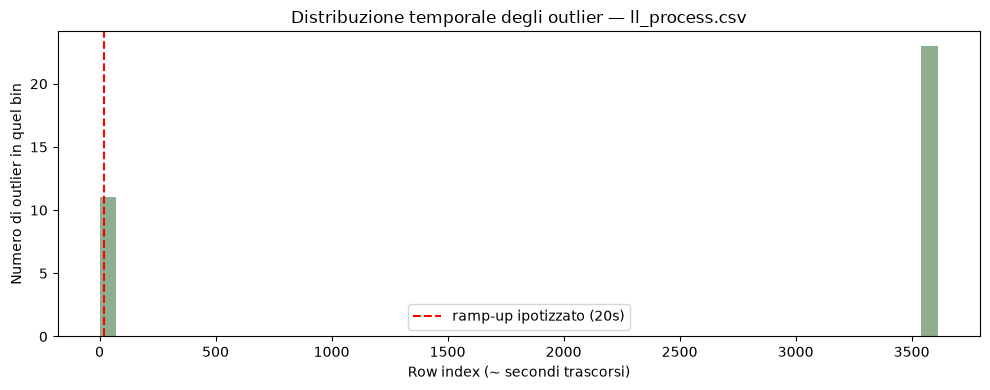

In [7]:
csv_path = Path("data/raw/ll_process.csv")
df = load_dataset(csv_path)

outliers = find_outlier_rows(df, z_threshold=4.0)
print(f"{len(outliers)} outlier rows su {len(df)} totali ({len(outliers)/len(df)*100:.2f}%)")
print(f"Indice minimo: {outliers.index.min()}, massimo: {outliers.index.max()}, mediana: {outliers.index.to_series().median()}")

plt.figure(figsize=(10, 4))
plt.hist(outliers.index, bins=50, color="#8fae8f")
plt.xlabel("Row index (~ secondi trascorsi)")
plt.ylabel("Numero di outlier in quel bin")
plt.title(f"Distribuzione temporale degli outlier — {csv_path.name}")
plt.axvline(x=20, color="red", linestyle="--", label="ramp-up ipotizzato (20s)")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / f"outlier_timeline_{csv_path.stem}.png")
plt.show()

In [8]:
for name in ["ll_global_clean", "ll_process_clean", "hl_report_clean"]:
    df = pd.read_csv(f"data/processed/{name}.csv")
    print(name, df.shape)

ll_global_clean (3560, 13)
ll_process_clean (3560, 6)
hl_report_clean (679046, 6)


In [9]:
import numpy as np
from pathlib import Path
from analysis.build_synthetic_workload import build_synthetic_manifest

row_labels = np.load("analysis/plots/hl_report_clean_pca_chunked/row_final_labels.npy")
manifest = build_synthetic_manifest(
    csv_path=Path("data/processed/hl_report_clean.csv"),
    row_final_labels=row_labels,
)
print(manifest)
manifest.to_csv("data/processed/synthetic_workload_manifest.csv", index=False)

    cluster           resource  count_in_cluster  cluster_size
0         1  Sample_2.14MB.bin                 1             2
1         2   Sample_139KB.bin                 1             1
2         3   Sample_1.3MB.bin                 1             1
3         4   Sample_139KB.bin                 2             6
4         5    Sample_20KB.bin                 1             3
5         6   Sample_514KB.bin                 3            14
6         7  Sample_9.21MB.bin              8489         33547
7         8  Sample_5.07MB.bin              1752          6367
8         9  Sample_99.7KB.bin             12600        153223
9        10  Sample_13.5KB.bin             33556        485444
10       11  Sample_9.21MB.bin                 1             2
11       12  Sample_0.99MB.bin                 4            21
12       13    Sample_98KB.bin                35           372
13       14  Sample_9.38MB.bin                 5            11
14       15  Sample_5.07MB.bin                15       

In [10]:
from analysis.build_synthetic_workload import build_weighted_synthetic_pool

weighted_pool = build_weighted_synthetic_pool(manifest, min_cluster_size=50, total_weight_budget=100)
print(weighted_pool)
weighted_pool.to_csv("data/processed/synthetic_workload_weighted.csv", index=False)

[INFO] Dropped 10 minor clusters (< 50 rows), that cover only 0.014% of total traffic.
            resource  cluster_size  weight
0  Sample_13.5KB.bin        485444      71
1  Sample_99.7KB.bin        153223      23
2  Sample_9.21MB.bin         33547       5
3  Sample_5.07MB.bin          6367       1
4    Sample_98KB.bin           372       1
